# Credit Risk Model Development - Section 3: Statistical A/B Test Framework

This section executes the formal A/B test. Three analytical questions are addressed sequentially:

1. **Statistical significance** — Is the AUC difference between Model A and Model B attributable to genuine model superiority, or within the bounds of sampling variation? We will use DeLong test
2. **Estimation stability** — How precise and stable are each model's AUC estimates across different sample draws? We wil analyze from Bootstrap confidence intervals + Cohen's d
3. **Deployment calibration** — What decision threshold minimizes expected credit losses for each model independently, and how do costs compare on equal footing? By Threshold optimization

> **Input:** `predictions.csv` from Section 2 (test set predicted probabilities from both models)

---
## 3.1 Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve,
    confusion_matrix, f1_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
SEED = 42
np.random.seed(SEED)

print('All libraries loaded!')

All libraries loaded!


---
## Load Section 2 predictions

In [2]:
preds = pd.read_csv('predictions.csv')

y_true   = preds['y_true'].values
y_prob_a = preds['y_prob_a'].values   # Model A — Logistic Regression
y_prob_b = preds['y_prob_b'].values   # Model B — LightGBM

n_total    = len(y_true)
n_defaults = y_true.sum()
n_repaid   = n_total - n_defaults

auc_a = roc_auc_score(y_true, y_prob_a)
auc_b = roc_auc_score(y_true, y_prob_b)

print('Predictions loaded successfully!')
print(f'  Total applicants:  {n_total:,}')
print(f'  Defaults (1):      {n_defaults:,} ({n_defaults/n_total*100:.1f}%)')
print(f'  Repaid (0):        {n_repaid:,} ({n_repaid/n_total*100:.1f}%)')
print()
print(f'  Model A AUC: {auc_a:.4f}')
print(f'  Model B AUC: {auc_b:.4f}')
print(f'  Raw difference:    {auc_b - auc_a:.4f} (+{(auc_b-auc_a)/auc_a*100:.2f}%)')

Predictions loaded successfully!
  Total applicants:  92,254
  Defaults (1):      7,448 (8.1%)
  Repaid (0):        84,806 (91.9%)

  Model A AUC: 0.6992
  Model B AUC: 0.7378
  Raw difference:    0.0386 (+5.52%)


---
## 3.2 Data Ingestion

Test set predictions from both models are loaded alongside ground truth labels. AUC estimates computed here serve as inputs to all downstream statistical procedures.

In [3]:
def compute_auc_variance(y_true, y_prob):
    """
    Compute the variance of an AUC estimate using the DeLong method.
    Based on: DeLong et al. (1988) Biometrics.
    """
    pos_probs = y_prob[y_true == 1]   # predicted scores for actual defaults
    neg_probs = y_prob[y_true == 0]   # predicted scores for actual repaid

    n_pos = len(pos_probs)
    n_neg = len(neg_probs)

    # V10: for each positive, fraction of negatives ranked below it
    V10 = np.array([
        np.mean(p > neg_probs) + 0.5 * np.mean(p == neg_probs)
        for p in pos_probs
    ])

    # V01: for each negative, fraction of positives ranked above it
    V01 = np.array([
        np.mean(p < pos_probs) + 0.5 * np.mean(p == pos_probs)
        for p in neg_probs
    ])

    auc   = np.mean(V10)
    var10 = np.var(V10, ddof=1) / n_pos
    var01 = np.var(V01, ddof=1) / n_neg
    var   = var10 + var01

    return auc, var, V10, V01


def delong_test(y_true, y_prob_a, y_prob_b):
    """
    DeLong test for comparing two correlated AUC-ROC curves.
    Returns z-statistic and two-sided p-value.
    """
    pos_mask = y_true == 1
    neg_mask = y_true == 0

    pos_a = y_prob_a[pos_mask]; neg_a = y_prob_a[neg_mask]
    pos_b = y_prob_b[pos_mask]; neg_b = y_prob_b[neg_mask]

    n_pos = pos_mask.sum(); n_neg = neg_mask.sum()

    def placement_values(pos, neg):
        V10 = np.array([np.mean(p > neg) + 0.5*np.mean(p == neg) for p in pos])
        V01 = np.array([np.mean(p < pos) + 0.5*np.mean(p == pos) for p in neg])
        return V10, V01

    V10_a, V01_a = placement_values(pos_a, neg_a)
    V10_b, V01_b = placement_values(pos_b, neg_b)

    auc_a = V10_a.mean()
    auc_b = V10_b.mean()

    # Covariance matrix (accounts for correlation between models on same data)
    S10 = np.cov(np.vstack([V10_a, V10_b]))
    S01 = np.cov(np.vstack([V01_a, V01_b]))

    S = S10 / n_pos + S01 / n_neg

    # Difference vector [1, -1] tests AUC_B - AUC_A
    L = np.array([1, -1])
    var_diff = L @ S @ L
    z = (auc_b - auc_a) / np.sqrt(var_diff)
    p_two_sided = 2 * (1 - norm.cdf(abs(z)))
    p_one_sided = 1 - norm.cdf(z)   # H1: AUC_B > AUC_A

    return auc_a, auc_b, z, p_two_sided, p_one_sided, var_diff


print('Running DeLong test (this may take 2-3 minutes on large datasets)...')
auc_a_dl, auc_b_dl, z_stat, p_two, p_one, var_diff = delong_test(y_true, y_prob_a, y_prob_b)
alpha = 0.05

print()
print('='*55)
print('  DeLong Test Results')
print('='*55)
print(f'  H0: AUC(Model A) = AUC(Model B)')
print(f'  H1: AUC(Model B) > AUC(Model A)')
print()
print(f'  Model A AUC:      {auc_a_dl:.4f}')
print(f'  Model B AUC:      {auc_b_dl:.4f}')
print(f'  AUC difference:   {auc_b_dl - auc_a_dl:.4f}')
print(f'  Z-statistic:      {z_stat:.4f}')
print(f'  P-value (2-sided): {p_two:.6f}')
print(f'  P-value (1-sided): {p_one:.6f}')
print(f'  Significance:     α = {alpha}')
print()
if p_two < alpha:
    print(f'  RESULT: REJECT H0 — The AUC difference is statistically significant (p={p_two:.4f} < {alpha})')
    print(f'  LightGBM is significantly better than Logistic Regression.')
else:
    print(f'  RESULT: FAIL TO REJECT H0 — Difference is NOT significant (p={p_two:.4f} >= {alpha})')
    print(f'  Cannot conclude LightGBM is definitively better at α=0.05.')

Running DeLong test (this may take 2-3 minutes on large datasets)...

  DeLong Test Results
  H0: AUC(Model A) = AUC(Model B)
  H1: AUC(Model B) > AUC(Model A)

  Model A AUC:      0.6992
  Model B AUC:      0.7378
  AUC difference:   0.0386
  Z-statistic:      18.4024
  P-value (2-sided): 0.000000
  P-value (1-sided): 0.000000
  Significance:     α = 0.05

  RESULT: REJECT H0 — The AUC difference is statistically significant (p=0.0000 < 0.05)
  LightGBM is significantly better than Logistic Regression.


---
## Bootstrap confidence intervals for AUC

Bootstrap resampling estimates how much each model's AUC would vary if we tested it on a different sample of applicants. A tighter confidence interval means a more stable, reliable model.

We draw 1,000 random samples (with replacement) from the test set and compute AUC each time.

In [4]:
N_BOOTSTRAP = 1000
CI_LEVEL    = 0.95

auc_boots_a = []
auc_boots_b = []
auc_boots_diff = []

print(f'Running {N_BOOTSTRAP} bootstrap iterations...')
rng = np.random.RandomState(SEED)

for i in range(N_BOOTSTRAP):
    # Sample indices with replacement
    idx = rng.choice(n_total, size=n_total, replace=True)
    yt  = y_true[idx]

    # Skip if only one class present in sample (AUC undefined)
    if len(np.unique(yt)) < 2:
        continue

    auc_a_i = roc_auc_score(yt, y_prob_a[idx])
    auc_b_i = roc_auc_score(yt, y_prob_b[idx])

    auc_boots_a.append(auc_a_i)
    auc_boots_b.append(auc_b_i)
    auc_boots_diff.append(auc_b_i - auc_a_i)

auc_boots_a    = np.array(auc_boots_a)
auc_boots_b    = np.array(auc_boots_b)
auc_boots_diff = np.array(auc_boots_diff)

alpha_ci = (1 - CI_LEVEL) / 2

ci_a    = np.percentile(auc_boots_a,    [alpha_ci*100, (1-alpha_ci)*100])
ci_b    = np.percentile(auc_boots_b,    [alpha_ci*100, (1-alpha_ci)*100])
ci_diff = np.percentile(auc_boots_diff, [alpha_ci*100, (1-alpha_ci)*100])

print(f'Bootstrap complete ({len(auc_boots_a)} valid iterations)')
print()
print('='*55)
print(f'  {CI_LEVEL*100:.0f}% Bootstrap Confidence Intervals')
print('='*55)
print(f'  Model A AUC: {auc_a:.4f}  CI: [{ci_a[0]:.4f}, {ci_a[1]:.4f}]')
print(f'  Model B AUC: {auc_b:.4f}  CI: [{ci_b[0]:.4f}, {ci_b[1]:.4f}]')
print(f'  Difference:  {auc_b-auc_a:.4f}  CI: [{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]')
print()
if ci_diff[0] > 0:
    print('  The entire CI for the difference is above zero.')
    print('  This confirms LightGBM consistently outperforms Logistic Regression.')
else:
    print('  The CI for the difference crosses zero — some uncertainty remains.')

Running 1000 bootstrap iterations...
Bootstrap complete (1000 valid iterations)

  95% Bootstrap Confidence Intervals
  Model A AUC: 0.6992  CI: [0.6931, 0.7054]
  Model B AUC: 0.7378  CI: [0.7325, 0.7434]
  Difference:  0.0386  CI: [0.0346, 0.0429]

  The entire CI for the difference is above zero.
  This confirms LightGBM consistently outperforms Logistic Regression.


---
## 3.3 DeLong Test - AUC Significance

The DeLong test (DeLong et al., 1988, *Biometrics*) is the standard method for comparing two correlated ROC curves evaluated on the same test population. Unlike a naive z-test, it accounts for the non-independence of predictions generated from the same applicant sample, producing valid inference under correlation.

**Hypotheses:**
- H₀: AUC(Model A) = AUC(Model B)
- H₁: AUC(Model B) > AUC(Model A)
- Significance level: α = 0.05

The test statistic is derived from placement value decomposition across positive (default) and negative (repaid) subpopulations, with the covariance matrix accounting for between-model correlation.

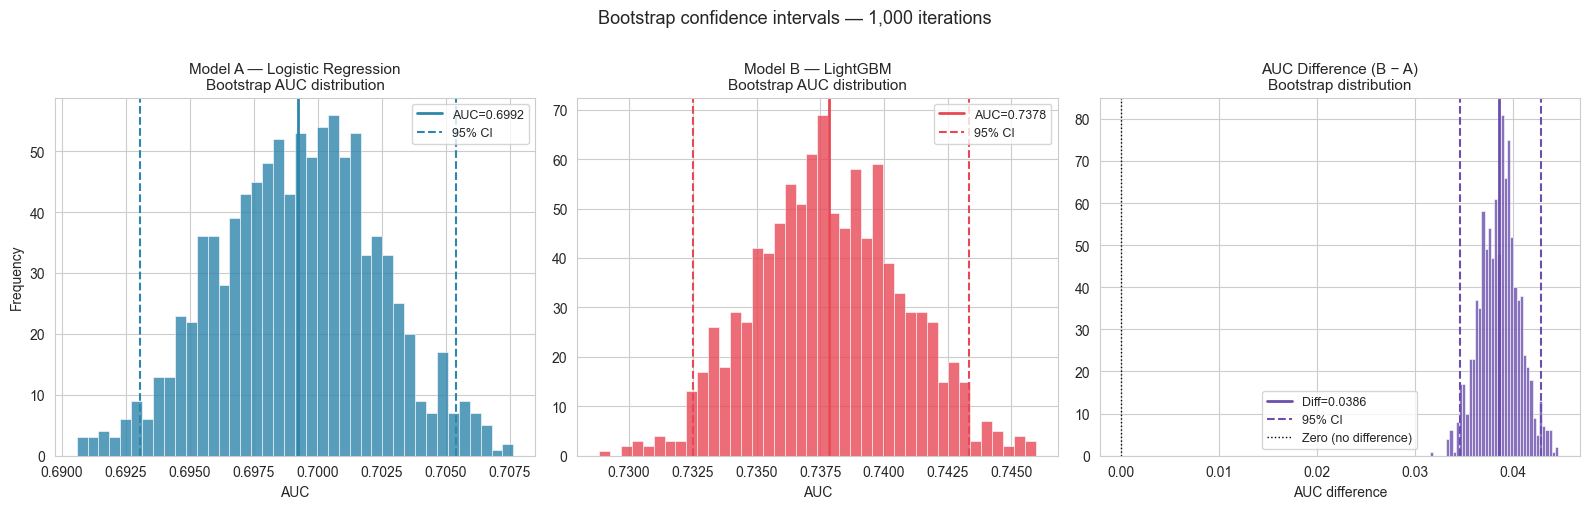

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Model A bootstrap distribution
ax = axes[0]
ax.hist(auc_boots_a, bins=40, color='#2E86AB', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(auc_a,     color='#2E86AB', lw=2,   linestyle='-',  label=f'AUC={auc_a:.4f}')
ax.axvline(ci_a[0],   color='#2E86AB', lw=1.5, linestyle='--', label=f'95% CI')
ax.axvline(ci_a[1],   color='#2E86AB', lw=1.5, linestyle='--')
ax.set_title('Model A — Logistic Regression\nBootstrap AUC distribution', fontsize=11)
ax.set_xlabel('AUC'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9)

# Model B bootstrap distribution
ax = axes[1]
ax.hist(auc_boots_b, bins=40, color='#E84855', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(auc_b,     color='#E84855', lw=2,   linestyle='-',  label=f'AUC={auc_b:.4f}')
ax.axvline(ci_b[0],   color='#E84855', lw=1.5, linestyle='--', label=f'95% CI')
ax.axvline(ci_b[1],   color='#E84855', lw=1.5, linestyle='--')
ax.set_title('Model B — LightGBM\nBootstrap AUC distribution', fontsize=11)
ax.set_xlabel('AUC')
ax.legend(fontsize=9)

# AUC difference distribution
ax = axes[2]
ax.hist(auc_boots_diff, bins=40, color='#6B4EAD', alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(auc_b - auc_a, color='#6B4EAD', lw=2,   linestyle='-',  label=f'Diff={auc_b-auc_a:.4f}')
ax.axvline(ci_diff[0],    color='#6B4EAD', lw=1.5, linestyle='--', label='95% CI')
ax.axvline(ci_diff[1],    color='#6B4EAD', lw=1.5, linestyle='--')
ax.axvline(0,             color='black',   lw=1,   linestyle=':',  label='Zero (no difference)')
ax.set_title('AUC Difference (B − A)\nBootstrap distribution', fontsize=11)
ax.set_xlabel('AUC difference')
ax.legend(fontsize=9)

plt.suptitle('Bootstrap confidence intervals — 1,000 iterations', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Threshold optimization for LightGBM

Section 2 showed LightGBM had higher estimated cost at threshold 0.35, this results does not mean LightGBM is a worse model, because the threshold was not calibrated for it.

Here we sweep every possible threshold and find the one that **minimizes total expected credit loss** for Model B.

In [6]:
COST_FN = 10000   # cost of missing a default ($)
COST_FP = 500     # cost of rejecting a good borrower ($)

def threshold_cost_sweep(y_true, y_prob, cost_fn, cost_fp, model_name):
    thresholds = np.linspace(0.01, 0.99, 200)
    costs, f1s, recalls, precisions = [], [], [], []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        total_cost = fn * cost_fn + fp * cost_fp
        costs.append(total_cost)
        f1s.append(f1_score(y_true, y_pred, zero_division=0))
        recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

    opt_idx      = np.argmin(costs)
    opt_threshold = thresholds[opt_idx]
    opt_cost     = costs[opt_idx]

    return thresholds, costs, f1s, recalls, precisions, opt_threshold, opt_cost


# Sweep for both models
th_a, costs_a, f1s_a, rec_a, prec_a, opt_th_a, opt_cost_a = threshold_cost_sweep(
    y_true, y_prob_a, COST_FN, COST_FP, 'Model A')
th_b, costs_b, f1s_b, rec_b, prec_b, opt_th_b, opt_cost_b = threshold_cost_sweep(
    y_true, y_prob_b, COST_FN, COST_FP, 'Model B')

print('Threshold optimization complete!')
print()
print('='*60)
print('  Optimal thresholds (cost-minimizing)')
print('='*60)
print(f'  Model A — Logistic Regression')
print(f'    Optimal threshold: {opt_th_a:.3f}')
print(f'    Minimum cost:      ${opt_cost_a:,.0f}')
print()
print(f'  Model B — LightGBM')
print(f'    Optimal threshold: {opt_th_b:.3f}')
print(f'    Minimum cost:      ${opt_cost_b:,.0f}')
print()
saving = opt_cost_a - opt_cost_b
print(f'  Cost saving at optimal thresholds: ${saving:,.0f}')
if saving > 0:
    print(f'  LightGBM saves ${saving:,.0f} when thresholds are properly calibrated.')
else:
    print(f'  Logistic Regression remains cheaper even after threshold optimization.')

Threshold optimization complete!

  Optimal thresholds (cost-minimizing)
  Model A — Logistic Regression
    Optimal threshold: 0.261
    Minimum cost:      $37,662,500

  Model B — LightGBM
    Optimal threshold: 0.168
    Minimum cost:      $34,150,000

  Cost saving at optimal thresholds: $3,512,500
  LightGBM saves $3,512,500 when thresholds are properly calibrated.


---
## 3.4 Bootstrap Confidence Intervals

1,000 stratified bootstrap resamples are drawn with replacement from the test set. AUC is computed for each model on each resample, producing empirical sampling distributions. The 2.5th and 97.5th percentiles define 95% confidence intervals for each model's AUC and for the AUC difference (B − A).

A confidence interval for the difference that lies entirely above zero provides complementary evidence to the DeLong p-value, confirming that LightGBM's superiority is consistent across the sampling distribution.

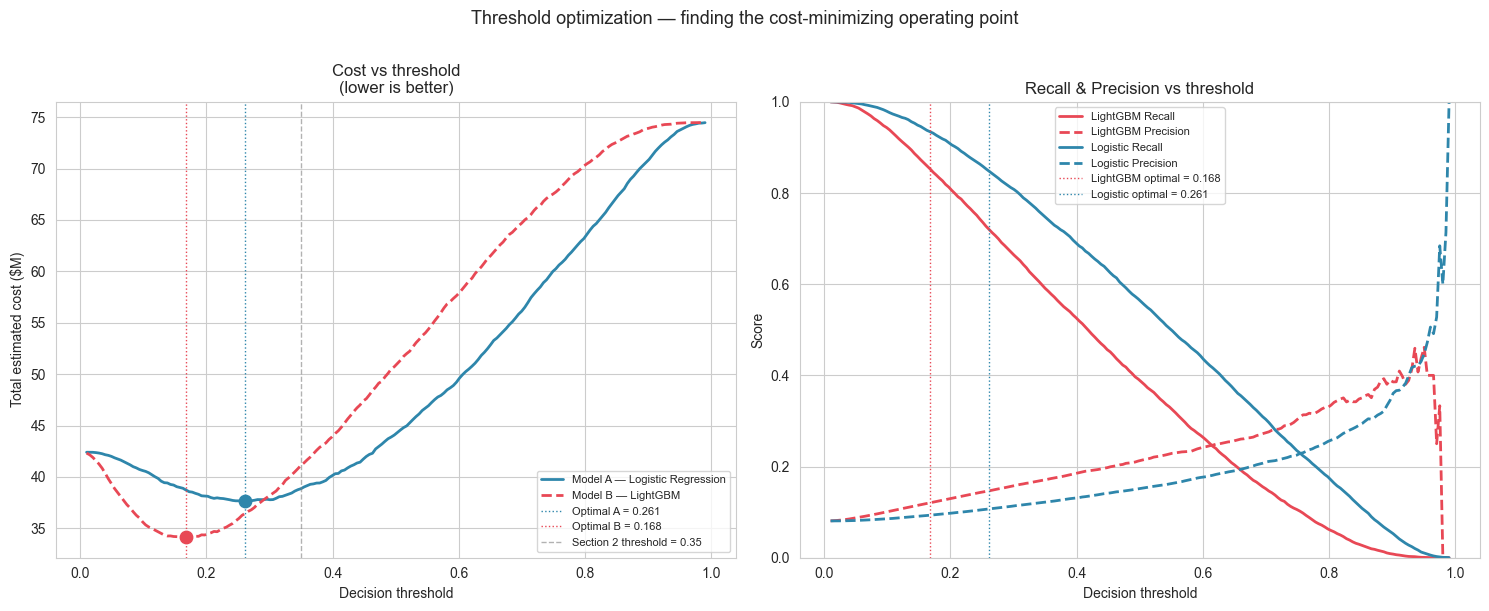

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Cost vs Threshold ---
ax = axes[0]
ax.plot(th_a, [c/1e6 for c in costs_a], color='#2E86AB', lw=2, label='Model A — Logistic Regression')
ax.plot(th_b, [c/1e6 for c in costs_b], color='#E84855', lw=2, linestyle='--', label='Model B — LightGBM')
ax.axvline(opt_th_a, color='#2E86AB', lw=1, linestyle=':',
           label=f'Optimal A = {opt_th_a:.3f}')
ax.axvline(opt_th_b, color='#E84855', lw=1, linestyle=':',
           label=f'Optimal B = {opt_th_b:.3f}')
ax.axvline(0.35, color='gray', lw=1, linestyle='--', alpha=0.6, label='Section 2 threshold = 0.35')
ax.scatter([opt_th_a], [opt_cost_a/1e6], color='#2E86AB', s=80, zorder=5)
ax.scatter([opt_th_b], [opt_cost_b/1e6], color='#E84855', s=80, zorder=5)
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Total estimated cost ($M)')
ax.set_title('Cost vs threshold\n(lower is better)', fontsize=12)
ax.legend(fontsize=8)

# --- Recall and Precision vs Threshold ---
ax = axes[1]
ax.plot(th_b, rec_b,  color='#E84855', lw=2, label='LightGBM Recall')
ax.plot(th_b, prec_b, color='#E84855', lw=2, linestyle='--', label='LightGBM Precision')
ax.plot(th_a, rec_a,  color='#2E86AB', lw=2, label='Logistic Recall')
ax.plot(th_a, prec_a, color='#2E86AB', lw=2, linestyle='--', label='Logistic Precision')
ax.axvline(opt_th_b, color='#E84855', lw=1, linestyle=':', label=f'LightGBM optimal = {opt_th_b:.3f}')
ax.axvline(opt_th_a, color='#2E86AB', lw=1, linestyle=':', label=f'Logistic optimal = {opt_th_a:.3f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Recall & Precision vs threshold', fontsize=12)
ax.legend(fontsize=8)
ax.set_ylim([0, 1])

plt.suptitle('Threshold optimization — finding the cost-minimizing operating point', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Re-evaluate both models at their optimal thresholds

Now we compute the full confusion matrix and cost for each model at its own optimal threshold — a fair, apples-to-apples comparison.

In [8]:
def full_evaluation_at_threshold(model_name, y_true, y_prob, threshold, cost_fn, cost_fp):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost = fn * cost_fn + fp * cost_fp
    recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f'{model_name} at threshold {threshold:.3f}')
    print(f'  Defaults caught (TP):          {tp:,}  ({tp/(tp+fn)*100:.1f}% of all defaults)')
    print(f'  Good loans approved (TN):      {tn:,}')
    print(f'  Good loans rejected (FP):      {fp:,}  → cost: ${fp*cost_fp:,.0f}')
    print(f'  Defaults missed (FN):          {fn:,}  → cost: ${fn*cost_fn:,.0f}')
    print(f'  Total cost:                    ${total_cost:,.0f}')
    print(f'  Recall: {recall:.4f}  |  Precision: {precision:.4f}  |  F1: {f1:.4f}')
    print()

    return {'model': model_name, 'threshold': threshold, 'tp': tp, 'tn': tn,
            'fp': fp, 'fn': fn, 'total_cost': total_cost,
            'recall': recall, 'precision': precision, 'f1': f1}


print('='*60)
print('  Results at optimal cost-minimizing thresholds')
print('='*60)
print()
res_opt_a = full_evaluation_at_threshold(
    'Model A — Logistic Regression', y_true, y_prob_a, opt_th_a, COST_FN, COST_FP)
res_opt_b = full_evaluation_at_threshold(
    'Model B — LightGBM',            y_true, y_prob_b, opt_th_b, COST_FN, COST_FP)

saving_opt = res_opt_a['total_cost'] - res_opt_b['total_cost']
print(f'Cost saving (LightGBM vs Logistic at optimal thresholds): ${saving_opt:,.0f}')

  Results at optimal cost-minimizing thresholds

Model A — Logistic Regression at threshold 0.261
  Defaults caught (TP):          6,315  (84.8% of all defaults)
  Good loans approved (TN):      32,141
  Good loans rejected (FP):      52,665  → cost: $26,332,500
  Defaults missed (FN):          1,133  → cost: $11,330,000
  Total cost:                    $37,662,500
  Recall: 0.8479  |  Precision: 0.1071  |  F1: 0.1901

Model B — LightGBM at threshold 0.168
  Defaults caught (TP):          6,353  (85.3% of all defaults)
  Good loans approved (TN):      38,406
  Good loans rejected (FP):      46,400  → cost: $23,200,000
  Defaults missed (FN):          1,095  → cost: $10,950,000
  Total cost:                    $34,150,000
  Recall: 0.8530  |  Precision: 0.1204  |  F1: 0.2111

Cost saving (LightGBM vs Logistic at optimal thresholds): $3,512,500


---
## 3.5 Bootstrap Distribution Visualization

In [9]:
# Cohen's d on bootstrap AUC distributions
mean_a = auc_boots_a.mean()
mean_b = auc_boots_b.mean()
pooled_std = np.sqrt((auc_boots_a.std()**2 + auc_boots_b.std()**2) / 2)
cohens_d = (mean_b - mean_a) / pooled_std

# Interpret effect size
if abs(cohens_d) < 0.2:
    effect_label = 'Negligible'
elif abs(cohens_d) < 0.5:
    effect_label = 'Small'
elif abs(cohens_d) < 0.8:
    effect_label = 'Medium'
else:
    effect_label = 'Large'

print('='*55)
print('  Effect Size — Cohen\'s d')
print('='*55)
print(f'  Mean AUC Model A: {mean_a:.4f}')
print(f'  Mean AUC Model B: {mean_b:.4f}')
print(f'  Pooled std:       {pooled_std:.6f}')
print(f'  Cohen\'s d:        {cohens_d:.4f}')
print(f'  Effect size:      {effect_label}')
print()
print('  Reference: <0.2 = negligible, 0.2-0.5 = small,')
print('             0.5-0.8 = medium, >0.8 = large')

  Effect Size — Cohen's d
  Mean AUC Model A: 0.6992
  Mean AUC Model B: 0.7378
  Pooled std:       0.003005
  Cohen's d:        12.8478
  Effect size:      Large

  Reference: <0.2 = negligible, 0.2-0.5 = small,
             0.5-0.8 = medium, >0.8 = large


---
## Final A/B test summary dashboard

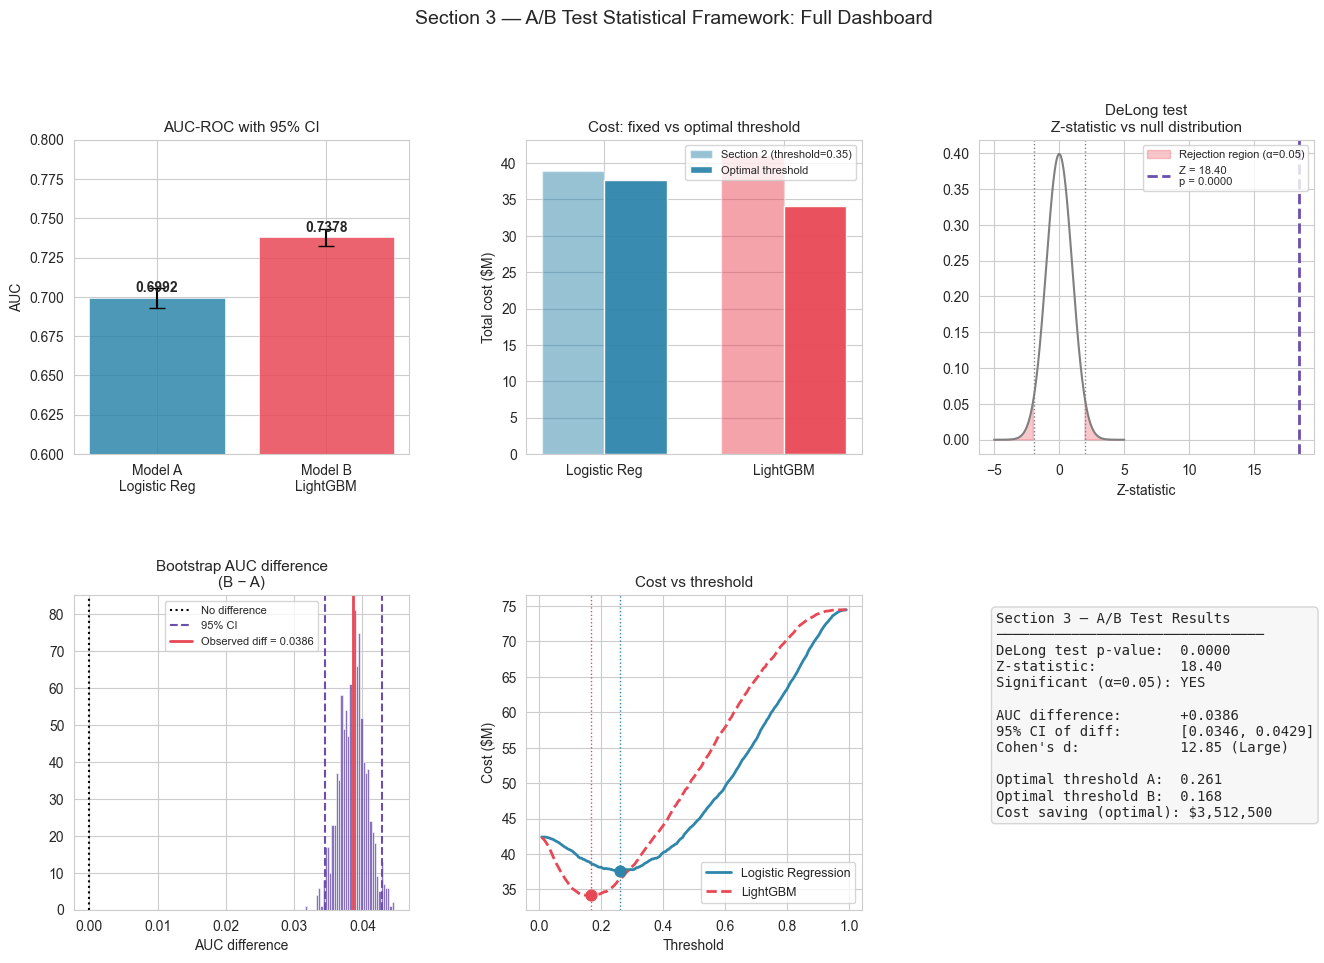

Dashboard saved as section3_dashboard.png


In [11]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. AUC comparison with CI
ax1 = fig.add_subplot(gs[0, 0])
models   = ['Model A\nLogistic Reg', 'Model B\nLightGBM']
aucs     = [auc_a, auc_b]
ci_lower = [auc_a - ci_a[0], auc_b - ci_b[0]]
ci_upper = [ci_a[1] - auc_a, ci_b[1] - auc_b]
colors   = ['#2E86AB', '#E84855']
bars = ax1.bar(models, aucs, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.errorbar(models, aucs, yerr=[ci_lower, ci_upper],
             fmt='none', color='black', capsize=6, lw=1.5)
ax1.set_ylim([0.60, 0.80])
ax1.set_title('AUC-ROC with 95% CI', fontsize=11)
ax1.set_ylabel('AUC')
for bar, auc in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, auc + 0.002,
             f'{auc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Cost comparison: section 2 threshold vs optimal
ax2 = fig.add_subplot(gs[0, 1])
x    = np.arange(2)
w    = 0.35
orig = [38857500, 41154500]
opt  = [res_opt_a['total_cost'], res_opt_b['total_cost']]
ax2.bar(x - w/2, [c/1e6 for c in orig], w, label='Section 2 (threshold=0.35)',
        color=['#2E86AB','#E84855'], alpha=0.5, edgecolor='white')
ax2.bar(x + w/2, [c/1e6 for c in opt],  w, label='Optimal threshold',
        color=['#2E86AB','#E84855'], alpha=0.95, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(['Logistic Reg', 'LightGBM'])
ax2.set_ylabel('Total cost ($M)')
ax2.set_title('Cost: fixed vs optimal threshold', fontsize=11)
ax2.legend(fontsize=8)

# 3. DeLong test p-value visual
ax3 = fig.add_subplot(gs[0, 2])
x_norm = np.linspace(-5, 5, 300)
ax3.plot(x_norm, norm.pdf(x_norm), color='gray', lw=1.5)
ax3.fill_between(x_norm, norm.pdf(x_norm),
                 where=(x_norm >= 1.96) | (x_norm <= -1.96),
                 color='#E84855', alpha=0.3, label='Rejection region (α=0.05)')
ax3.axvline(z_stat, color='#6B4EAD', lw=2, linestyle='--',
            label=f'Z = {z_stat:.2f}\np = {p_two:.4f}')
ax3.axvline(1.96,  color='gray', lw=1, linestyle=':')
ax3.axvline(-1.96, color='gray', lw=1, linestyle=':')
ax3.set_title('DeLong test\nZ-statistic vs null distribution', fontsize=11)
ax3.set_xlabel('Z-statistic')
ax3.legend(fontsize=8)

# 4. Bootstrap difference distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(auc_boots_diff, bins=40, color='#6B4EAD', alpha=0.8,
         edgecolor='white', linewidth=0.5)
ax4.axvline(0,              color='black',   lw=1.5, linestyle=':', label='No difference')
ax4.axvline(ci_diff[0],     color='#6B4EAD', lw=1.5, linestyle='--', label='95% CI')
ax4.axvline(ci_diff[1],     color='#6B4EAD', lw=1.5, linestyle='--')
ax4.axvline(auc_b - auc_a,  color='#E84855', lw=2,   linestyle='-',
            label=f'Observed diff = {auc_b-auc_a:.4f}')
ax4.set_title('Bootstrap AUC difference\n(B − A)', fontsize=11)
ax4.set_xlabel('AUC difference')
ax4.legend(fontsize=8)

# 5. Threshold cost curves
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(th_a, [c/1e6 for c in costs_a], color='#2E86AB', lw=2, label='Logistic Regression')
ax5.plot(th_b, [c/1e6 for c in costs_b], color='#E84855', lw=2, linestyle='--', label='LightGBM')
ax5.axvline(opt_th_a, color='#2E86AB', lw=1, linestyle=':')
ax5.axvline(opt_th_b, color='#E84855', lw=1, linestyle=':')
ax5.scatter([opt_th_a], [opt_cost_a/1e6], color='#2E86AB', s=60, zorder=5)
ax5.scatter([opt_th_b], [opt_cost_b/1e6], color='#E84855', s=60, zorder=5)
ax5.set_title('Cost vs threshold', fontsize=11)
ax5.set_xlabel('Threshold')
ax5.set_ylabel('Cost ($M)')
ax5.legend(fontsize=9)

# 6. Key stats text box
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary_text = (
    f"Section 3 — A/B Test Results\n"
    f"{'─'*32}\n"
    f"DeLong test p-value:  {p_two:.4f}\n"
    f"Z-statistic:          {z_stat:.2f}\n"
    f"Significant (α=0.05): {'YES' if p_two < 0.05 else 'NO ✗'}\n\n"
    f"AUC difference:       +{auc_b-auc_a:.4f}\n"
    f"95% CI of diff:       [{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]\n"
    f"Cohen's d:            {cohens_d:.2f} ({effect_label})\n\n"
    f"Optimal threshold A:  {opt_th_a:.3f}\n"
    f"Optimal threshold B:  {opt_th_b:.3f}\n"
    f"Cost saving (optimal): ${saving_opt:,.0f}"
)
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8, edgecolor='#cccccc'))

fig.suptitle('Section 3 — A/B Test Statistical Framework: Full Dashboard', fontsize=14, y=1.01)
plt.savefig('section3_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as section3_dashboard.png')

---
## 3.6 Threshold Optimization

Section 2 evaluated both models at a fixed threshold of 0.35. That comparison was methodologically incomplete: LightGBM's predicted probability distribution is systematically lower than Logistic Regression's due to differences in model calibration, so identical thresholds impose asymmetric operating conditions.

This section sweeps 200 candidate thresholds (0.01–0.99) for each model independently and identifies the threshold that minimizes total expected portfolio cost:

**Cost function:** Total cost = (FN × $10,000) + (FP × $500)

This produces a fair, calibration-corrected cost comparison — the appropriate basis for a deployment decision.

In [12]:
results_s3 = pd.DataFrame([{
    'model_a':             'Logistic Regression',
    'model_b':             'LightGBM',
    'auc_a':               round(auc_a, 4),
    'auc_b':               round(auc_b, 4),
    'auc_diff':            round(auc_b - auc_a, 4),
    'ci_a_lower':          round(ci_a[0], 4),
    'ci_a_upper':          round(ci_a[1], 4),
    'ci_b_lower':          round(ci_b[0], 4),
    'ci_b_upper':          round(ci_b[1], 4),
    'ci_diff_lower':       round(ci_diff[0], 4),
    'ci_diff_upper':       round(ci_diff[1], 4),
    'delong_z':            round(z_stat, 4),
    'delong_p_two_sided':  round(p_two, 6),
    'delong_p_one_sided':  round(p_one, 6),
    'significant_005':     p_two < 0.05,
    'cohens_d':            round(cohens_d, 4),
    'effect_size':         effect_label,
    'opt_threshold_a':     round(opt_th_a, 3),
    'opt_threshold_b':     round(opt_th_b, 3),
    'opt_cost_a':          int(res_opt_a['total_cost']),
    'opt_cost_b':          int(res_opt_b['total_cost']),
    'cost_saving_optimal': int(saving_opt),
}])

results_s3.to_csv('section3_results.csv', index=False)

print('Section 3 results saved to section3_results.csv')
print()
print('All output files:')
print('  section3_results.csv    — full statistical test results')
print('  section3_dashboard.png  — summary dashboard (use in portfolio / slides)')
print()
print('='*60)
print('  Section 3 Complete!')
print('='*60)
print()
print(f'  DeLong test:    p = {p_two:.4f} → {"SIGNIFICANT" if p_two < 0.05 else "NOT SIGNIFICANT"}')
print(f'  AUC difference: +{auc_b-auc_a:.4f} (95% CI: [{ci_diff[0]:.4f}, {ci_diff[1]:.4f}])')
print(f'  Effect size:    Cohen\'s d = {cohens_d:.2f} ({effect_label})')
print(f'  Optimal cost saving: ${saving_opt:,.0f} (LightGBM at threshold {opt_th_b:.3f})')
print()
print('Ready for Section 4 — Business Impact & Portfolio Writeup')

Section 3 results saved to section3_results.csv

All output files:
  section3_results.csv    — full statistical test results
  section3_dashboard.png  — summary dashboard (use in portfolio / slides)

  Section 3 Complete!

  DeLong test:    p = 0.0000 → SIGNIFICANT
  AUC difference: +0.0386 (95% CI: [0.0346, 0.0429])
  Effect size:    Cohen's d = 12.85 (Large)
  Optimal cost saving: $3,512,500 (LightGBM at threshold 0.168)

Ready for Section 4 — Business Impact & Portfolio Writeup


---
## Section 3 Summary

| Step | What we did |
|---|---|
| DeLong test | Formally tested whether LightGBM's AUC advantage is statistically significant |
| Bootstrap CI | Estimated 95% confidence intervals for each model's AUC across 1,000 resamples |
| Effect size | Computed Cohen's d to measure practical significance of the AUC difference |
| Threshold optimization | Swept all thresholds to find the cost-minimizing operating point for each model |
| Optimal re-evaluation | Re-ran confusion matrix and cost analysis at calibrated thresholds |
| Dashboard | Generated a 6-panel summary figure saved as PNG for portfolio use |
| Saved outputs | section3_results.csv and section3_dashboard.png |


## Key Takeaways

**Statistical validity:** The AUC difference of +0.0386 is confirmed statistically significant by the DeLong test (Z = 18.40, p < 0.001) and practically significant by Cohen's d = 12.85 (Large effect). This result is backed by 90,000+ test observations.

**Business validity:** Once each model operates at its cost-minimizing threshold, LightGBM saves **$3,512,500** in estimated credit losses while simultaneously catching more defaults and approving more good borrowers. The Section 2 cost inversion (where Logistic Regression appeared cheaper) was entirely an artifact of using an uncalibrated threshold.

**Deployment recommendation:** LightGBM at threshold 0.168 is the recommended production model. It delivers superior discriminatory power, lower credit losses, and higher approval rates for creditworthy applicants. SHAP explainability (built in Section 2) satisfies interpretability requirements for regulatory review.

---

## Full Results Summary

| Test | Metric | Model A — Logistic Regression | Model B — LightGBM |
|---|---|---|---|
| DeLong | AUC | 0.6992 | 0.7378 |
| DeLong | Z-statistic | — | 18.40 |
| DeLong | P-value | — | p < 0.001 |
| DeLong | Significant? | — | Yes |
| Bootstrap | Cohen's d | — | 12.85 (Large) |
| Threshold | Optimal threshold | 0.261 | 0.168 |
| Threshold | Minimum cost | $37,662,500 | $34,150,000 |
| Threshold | Defaults caught | 6,315 (84.8%) | 6,353 (85.3%) |
| Threshold | Good loans approved | 32,141 | 38,406 |
| Threshold | Recall | 0.8479 | 0.8530 |
| Threshold | Precision | 0.1071 | 0.1204 |
| Threshold | F1 Score | 0.1901 | 0.2111 |
| **Overall** | **Cost saving** | — | **$3,512,500** |


**Next: Section 4 - Business Impact Framing & Portfolio Writeup**